In [4]:
import dask
import dask.distributed
from dask_util import DaskClient

In [5]:
client = DaskClient(local_params={"n_workers":1})

In [6]:
client.getNworkers()

1

In [10]:
%load_ext autoreload
%autoreload 2
import SepVector
import __pyDaskVector as DaskVector
import Hypercube

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [544]:

ns = [100, 100, 100]
os = [0,0,0]
ds = [1,1,1]
chunks = [4,4,10]

ax = Hypercube.axis(n=1, o=1, d=1)
hyp = Hypercube.hypercube(ns=ns, ds=ds, os=os)
vec = SepVector.getSepVector(ns=ns, ds=ds, os=os, storage='dataFloat')
vec.rand()

floatVector
Axis 1: n=100	o=0.000000	d=1.000000
Axis 2: n=100	o=0.000000	d=1.000000
Axis 3: n=100	o=0.000000	d=1.000000

In [545]:
# option 1
# creating from scratch
daskVec = DaskVector.DaskVector(client, vecCls=SepVector.floatVector, ns=ns, ds=ds, os=os, chunks=chunks)

[[0 0 0]
 [25 0 0]
 [50 0 0]
 [75 0 0]
 [0 25 0]
 [25 25 0]
 [50 25 0]
 [75 25 0]
 [0 50 0]
 [25 50 0]
 [50 50 0]
 [75 50 0]
 [0 75 0]
 [25 75 0]
 [50 75 0]
 [75 75 0]
 [0 0 10]
 [25 0 10]
 [50 0 10]
 [75 0 10]
 [0 25 10]
 [25 25 10]
 [50 25 10]
 [75 25 10]
 [0 50 10]
 [25 50 10]
 [50 50 10]
 [75 50 10]
 [0 75 10]
 [25 75 10]
 [50 75 10]
 [75 75 10]
 [0 0 20]
 [25 0 20]
 [50 0 20]
 [75 0 20]
 [0 25 20]
 [25 25 20]
 [50 25 20]
 [75 25 20]
 [0 50 20]
 [25 50 20]
 [50 50 20]
 [75 50 20]
 [0 75 20]
 [25 75 20]
 [50 75 20]
 [75 75 20]
 [0 0 30]
 [25 0 30]
 [50 0 30]
 [75 0 30]
 [0 25 30]
 [25 25 30]
 [50 25 30]
 [75 25 30]
 [0 50 30]
 [25 50 30]
 [50 50 30]
 [75 50 30]
 [0 75 30]
 [25 75 30]
 [50 75 30]
 [75 75 30]
 [0 0 40]
 [25 0 40]
 [50 0 40]
 [75 0 40]
 [0 25 40]
 [25 25 40]
 [50 25 40]
 [75 25 40]
 [0 50 40]
 [25 50 40]
 [50 50 40]
 [75 50 40]
 [0 75 40]
 [25 75 40]
 [50 75 40]
 [75 75 40]
 [0 0 50]
 [25 0 50]
 [50 0 50]
 [75 0 50]
 [0 25 50]
 [25 25 50]
 [50 25 50]
 [75 25 50]
 [0 50

In [467]:
np.repeat([0, 50], 2)

array([ 0,  0, 50, 50])

In [530]:
# option 2
# creating from existing in-memory SepVector
daskVec = DaskVector.DaskVector(client, from_vector=vec, chunks=chunks)

[ 0. 50.]
rep 1 [ 0. 50.]
ntile 4 [ 0. 50.  0. 50.  0. 50.  0. 50.]
[ 0. 25. 50. 75.]
rep 2 [ 0.  0. 25. 25. 50. 50. 75. 75.]
ntile 1 [ 0.  0. 25. 25. 50. 50. 75. 75.]
[[0.0 0.0]
 [50.0 0.0]
 [0.0 25.0]
 [50.0 25.0]
 [0.0 50.0]
 [50.0 50.0]
 [0.0 75.0]
 [50.0 75.0]]


In [462]:
np.repeat([0,50],4)

[autoreload of __pyDaskVector failed: Traceback (most recent call last):
  File "/usr/local/lib/python3.9/dist-packages/IPython/extensions/autoreload.py", line 261, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.9/dist-packages/IPython/extensions/autoreload.py", line 459, in superreload
    module = reload(module)
  File "/usr/lib/python3.9/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 613, in _exec
  File "<frozen importlib._bootstrap_external>", line 786, in exec_module
  File "<frozen importlib._bootstrap_external>", line 923, in get_code
  File "<frozen importlib._bootstrap_external>", line 853, in source_to_code
  File "<frozen importlib._bootstrap>", line 228, in _call_with_frames_removed
  File "/opt/python-solver/GenericSolver/python/__pyDaskVector.py", line 148
    oos = np.tile(oos, ntiles)
    ^
SyntaxError: invalid syntax
]


array([ 0,  0,  0,  0, 50, 50, 50, 50])

In [144]:
daskVec.set(1)
v2 = daskVec.clone()

In [532]:
daskVec.norm()

28.864505963003044

In [531]:
vec.norm()

28.864505767822266

In [434]:
daskVec.shape

[(50, 100), (50, 100)]

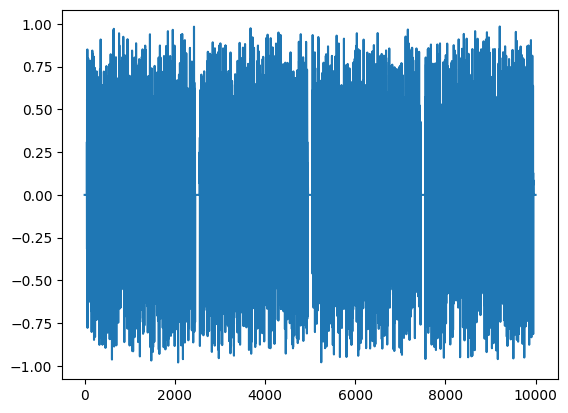

In [533]:
import matplotlib.pyplot as plt

flat1 = vec.getNdArray().flatten()
flat2 = np.concatenate(daskVec.getNdArray()).flatten()

plt.plot(flat1-flat2)